# Figure 2 — coarser meteorological forcing leaves the top metre wetter and richer in CO2

Figures compare to hourly by: 

$$\Delta\theta(z) = \langle\theta\rangle_{\text{case}}(z) - \langle\theta\rangle_{\text{hourly}}(z)
\qquad
\frac{\Delta p_{\mathrm{CO_2}}}{p_{\mathrm{CO_2}}}(z)
 = \frac{\langle p\rangle_{\text{case}}(z) - \langle p\rangle_{\text{hourly}}(z)}
        {\langle p\rangle_{\text{hourly}}(z)}$$

where $\langle\cdot\rangle$ is the time mean over the whole 10-year record.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patheffects import withStroke

# ----------------------------------------------------------------- knobs
FIG_W, FIG_H = 7.0, 5.0     # inches, both figures
SHOW_TITLE = False
SAVE = False                # write figures/fig2.{pdf,png} and figures/fig2_sites.{pdf,png}
DPI = 600                   # raster fallback; PDF is vector
BAND = (0, 1)               # ribbon quantiles across sites; (0, 1) is the full range
SITE_ALPHA = 0.55           # figure 2b: per-site line opacity
SITE_LW = 0.9               # figure 2b: per-site line width
XPAD = (0.15, 1.12)         # x-limits as a multiple of the largest offset in the window
TREAT = "ctrl"              # unamended: the question is what averaging the weather does to the soil
# ------------------------------------------------------------------------

CASES = ["hourly", "daily", "monthly", "longterm"]   # ordered coarse-ward
REFERENCE = "hourly"
SHOWN = [c for c in CASES if c != REFERENCE]         # hourly is the zero line, not a curve

MIX_DEPTH_CM = 30       # feedstock is mixed over the plough layer (till_depth_m = 0.30)
DEPTH_LIM = (150, 0)    # inverted: depth increases downward

STORE = ("s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations"
         "/postprocessed/met_forcing_rxn/soilwater_co2_profile_mean.zarr")
FIGDIR = Path("")       # where to save if SAVE = True

In [ ]:
# --- colour ------------------------------------------------------------------
CASE_COLOR = dict(zip(SHOWN, ["#3f8fe3", "#1857a9", "#0c2d61"]))
INK, MUTED = "#1a1a1a", "#5c5c5c"        # text tokens; never a series colour on text
HALO = [withStroke(linewidth=2.2, foreground="white")]   # keeps labels legible over ribbons
MARKER_KW = dict(marker="o", ms=3.6, mec="white", mew=0.7)

# --- print rc ----------------------------------------------------------------
PUB_RC = {
    "font.family": "sans-serif",
}

## 1. Read in data

In [9]:
pm = xr.open_zarr(STORE).load().sel(treat=TREAT)

SITES = [str(s) for s in pm["site"].values]
DEPTHS = [int(d) for d in pm["depth"].values]
assert set(CASES) == {str(c) for c in pm["case"].values}, "store does not carry all four cases"


def offsets(var, relative=False):
    """`{case: depth x site}` departure from that site's own hourly run."""
    da = pm[var]
    ref = da.sel(case=REFERENCE)
    out = {}
    for case in SHOWN:
        d = da.sel(case=case) - ref
        if relative:
            d = d / ref
        out[case] = (d.transpose("depth", "site").to_pandas()
                     .sort_index(ascending=False))     # deepest first, so the polygons close
    return out


def depth_mean(d, lo=0, hi=100):
    """Depth-weighted mean of an offset table over `lo`-`hi` cm, one value per site.

    depth-weighting necessary because the monitors are not evenly spaced. 
    """
    sub = d[(d.index >= lo) & (d.index <= hi)].sort_index()
    z = sub.index.to_numpy(dtype=float)
    return pd.Series(np.trapezoid(sub.to_numpy(), z, axis=0) / (z[-1] - z[0]),
                     index=sub.columns, name=f"{lo}-{hi} cm")


OFFSETS = offsets("theta")
CO2_OFFSETS = offsets("pco2", relative=True)

print(f"{len(SITES)} sites x {len(CASES)} cases x {len(DEPTHS)} depths, "
      f"treat = {TREAT}, from {STORE.rsplit('/', 1)[-1]}")
print("sites :", ", ".join(SITES))
print("depths:", DEPTHS)
print(f"\ninside the plotted window (0-{DEPTH_LIM[0]} cm), across all sites:")
for name, off, unit, scale in [("d_theta", OFFSETS, "m3/m3", 1), ("d_pco2/pco2", CO2_OFFSETS, "%", 100)]:
    for case in SHOWN:
        d = off[case] * scale
        d = d[d.index <= DEPTH_LIM[0]]
        print(f"  {name:12s} {case:9s} {d.min().min():+9.4f} to {d.max().max():+9.4f} {unit}")

8 sites x 4 cases x 21 depths, treat = ctrl, from soilwater_co2_profile_mean.zarr
sites : Cecil, Flanagan, HoustonBlack, Kalamazoo, Kuma, Palouse, Pullman, Yolo
depths: [0, 1, 5, 10, 20, 30, 40, 50, 51, 70, 81, 100, 101, 120, 130, 140, 150, 200, 201, 300, 301]

inside the plotted window (0-150 cm), across all sites:
  d_theta      daily       -0.0004 to   +0.0051 m3/m3
  d_theta      monthly     -0.0018 to   +0.0254 m3/m3
  d_theta      longterm    -0.0001 to   +0.0307 m3/m3
  d_pco2/pco2  daily       -0.1099 to  +10.3244 %
  d_pco2/pco2  monthly     +1.2454 to +100.8968 %
  d_pco2/pco2  longterm    +1.8603 to +161.1025 %


## 2. Figure 2 — site median and across-site range

The ribbon is the full range across the eight sites and the line is their median. Markers sit where
the model was actually sampled.

The x-limits are computed from the data rather than hard-coded, so a re-run moves them.

In [14]:
pm

<xarray.Dataset> Size: 6kB
Dimensions:  (site: 8, case: 4, depth: 21)
Coordinates:
  * site     (site) <U12 384B 'Cecil' 'Flanagan' ... 'Pullman' 'Yolo'
    state    (site) <U11 352B 'Northern SC' 'Central IL' ... 'Central CA'
  * case     (case) <U8 128B 'hourly' 'daily' 'monthly' 'longterm'
  * depth    (depth) int16 42B 0 1 5 10 20 30 40 ... 130 140 150 200 201 300 301
    treat    <U4 16B 'ctrl'
Data variables:
    pco2     (site, case, depth) float32 3kB 0.0004367 0.0005074 ... 0.002017
    theta    (site, case, depth) float32 3kB 0.2801 0.2813 ... 0.3979 0.3983
Attributes:
    title:        MIN3P met_forcing_rxn mean soil water and soil CO2 profiles
    description:  Ten-year record mean of volumetric water content and soil C...
    method:       trapezoid-rule time integral of the raw adaptive-timestep M...
    created_by:   figures/postprocess-data/create-soilwater+co2-columns.ipynb

largest site offset inside the window: 0.0307 m3/m3, 161% pCO2


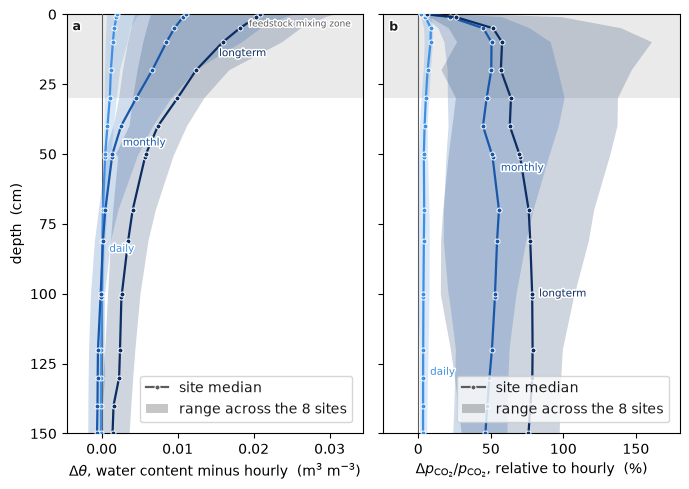

In [10]:
LABEL_DEPTH_H2O = {"longterm": 14, "monthly": 46, "daily": 84}
LABEL_DEPTH_CO2 = {"longterm": 100, "monthly": 55, "daily": 128}


def mixing_zone(ax):
    ax.axhspan(0, MIX_DEPTH_CM, color="#d9d9d9", alpha=0.55, lw=0, zorder=0)


def label_case(ax, med, case, z):
    """Direct-label a case on its own curve, at depth `z`."""
    ax.annotate(case, xy=(np.interp(z, med.index[::-1], med.to_numpy()[::-1]), z),
                xytext=(5, 0), textcoords="offset points", ha="left", va="center",
                color=CASE_COLOR[case], fontsize=7.5, path_effects=HALO, zorder=6)


def finish_panel(ax, off, scale=1.0):
    """The zero line, the depth axis, and x-limits that follow the data."""
    ax.axvline(0, color=MUTED, lw=0.8, zorder=3)          # hourly reference
    ax.set_yticks(np.arange(0, 401, 25))
    ax.set_ylim(*DEPTH_LIM)
    hi = max((off[c] * scale).loc[off[c].index <= DEPTH_LIM[0]].max().max() for c in SHOWN)
    ax.set_xlim(-XPAD[0] * hi, XPAD[1] * hi)
    return hi


def draw_panel(ax, off, label_depth, scale=1.0):
    """Ribbon = across-site range, line = site median, marker = a monitored depth."""
    mixing_zone(ax)

    # Widest ribbon first so the narrower ones stay visible on top of it.
    for case in reversed(SHOWN):
        d = off[case] * scale
        ax.fill_betweenx(d.index, d.quantile(BAND[0], axis=1), d.quantile(BAND[1], axis=1),
                         color=CASE_COLOR[case], alpha=0.20, lw=0, zorder=2)

    for case in SHOWN:
        d = off[case] * scale
        med = d.median(axis=1)
        ax.plot(med, d.index, color=CASE_COLOR[case], lw=1.6, solid_joinstyle="round",
                zorder=4, label=case, **MARKER_KW)
        label_case(ax, med, case, label_depth[case])

    return finish_panel(ax, off, scale)


def band_legend(ax, n_sites):
    label = (f"range across the {n_sites} sites" if BAND == (0, 1)
             else f"{BAND[0]:.0%}-{BAND[1]:.0%} of {n_sites} sites")
    ax.legend(handles=[Line2D([], [], color=MUTED, lw=1.6, label="site median", **MARKER_KW),
                       Patch(facecolor=MUTED, alpha=0.35, lw=0, label=label)],
              loc="lower right", handlelength=1.6, borderaxespad=0.8, labelcolor=INK)


def decorate(fig, ax_h2o, ax_co2):
    """Everything both figures share once their panels are drawn."""
    ax_h2o.text(0.975, 1.5, "feedstock mixing zone", transform=ax_h2o.get_yaxis_transform(),
                ha="right", va="top", fontsize=6.5, color=MUTED, path_effects=HALO, zorder=6)
    ax_h2o.set_xlabel(r"$\Delta\theta$, water content minus hourly  (m$^3$ m$^{-3}$)")
    ax_h2o.set_ylabel("depth  (cm)")
    ax_co2.set_xlabel(r"$\Delta p_{\mathrm{CO_2}}/p_{\mathrm{CO_2}}$, relative to hourly  (%)")
    for ax, tag in ((ax_h2o, "a"), (ax_co2, "b")):
        ax.text(0.02, 0.985, tag, transform=ax.transAxes, ha="left", va="top",
                fontsize=9, fontweight="bold", color=INK, path_effects=HALO, zorder=7)
    if SHOW_TITLE:
        fig.suptitle("Coarser forcing leaves the top metre wetter and richer in CO$_2$",
                     x=0.02, ha="left", color=INK)
    fig.tight_layout()


def save(fig, stem):
    if not SAVE:
        return
    for ext in ("pdf", "png"):
        fig.savefig(FIGDIR / f"{stem}.{ext}")
    print("wrote", ", ".join(str(FIGDIR / f"{stem}.{e}") for e in ("pdf", "png")))


with plt.rc_context(PUB_RC):
    fig, (ax_h2o, ax_co2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), sharey=True)

    h2o_max = draw_panel(ax_h2o, OFFSETS, LABEL_DEPTH_H2O)
    band_legend(ax_h2o, len(SITES))

    co2_max = draw_panel(ax_co2, CO2_OFFSETS, LABEL_DEPTH_CO2, scale=100)  # fraction -> per cent
    band_legend(ax_co2, len(SITES))

    decorate(fig, ax_h2o, ax_co2)
    save(fig, "fig2")

print(f"largest site offset inside the window: {h2o_max:.4f} m3/m3, {co2_max:.0f}% pCO2")
plt.show()

## 3. Figure 2b — as above but drawing every site

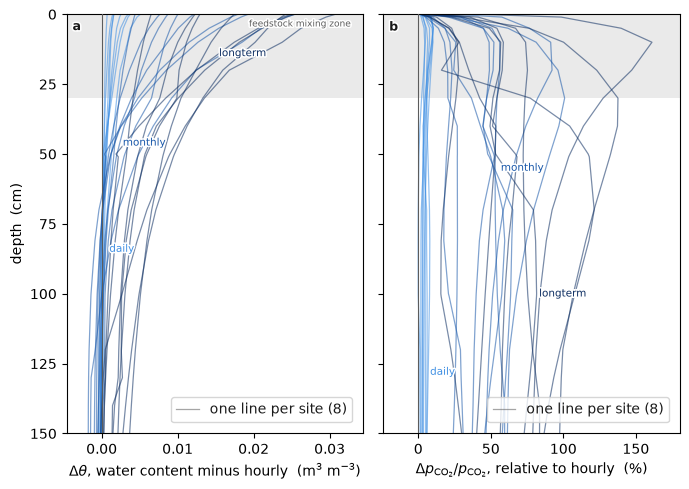

In [11]:
def draw_panel_sites(ax, off, label_depth, scale=1.0):
    """One faint line per site, coloured by case."""
    mixing_zone(ax)

    for case in SHOWN:
        d = off[case] * scale
        depth = np.broadcast_to(d.index.to_numpy()[:, None], d.shape)
        # A single plot call per case: matplotlib pairs the columns of x and y, so this
        # draws one line per site without a Python loop over sites.
        ax.plot(d.to_numpy(), depth, color=CASE_COLOR[case], lw=SITE_LW,
                alpha=SITE_ALPHA, solid_joinstyle="round", zorder=2)
        # Anchor the direct label on the (undrawn) median so it lands mid-bundle.
        label_case(ax, d.median(axis=1), case, label_depth[case])

    return finish_panel(ax, off, scale)


def site_legend(ax, n_sites):
    ax.legend(handles=[Line2D([], [], color=MUTED, lw=SITE_LW, alpha=SITE_ALPHA,
                              label=f"one line per site ({n_sites})")],
              loc="lower right", handlelength=1.6, borderaxespad=0.8, labelcolor=INK)


with plt.rc_context(PUB_RC):
    fig_b, (bx_h2o, bx_co2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), sharey=True)

    draw_panel_sites(bx_h2o, OFFSETS, LABEL_DEPTH_H2O)
    site_legend(bx_h2o, len(SITES))

    draw_panel_sites(bx_co2, CO2_OFFSETS, LABEL_DEPTH_CO2, scale=100)
    site_legend(bx_co2, len(SITES))

    decorate(fig_b, bx_h2o, bx_co2)
    save(fig_b, "fig2_sites")

plt.show()

## 4. Caption numbers

Depth averages are trapezoidal over the monitored depths, for the reason given in `depth_mean`.

In [12]:
def caption_table(off, scale=1.0, shallow="median site"):
    rows = []
    for case in SHOWN:
        d = off[case].astype(float) * scale
        top, deep = depth_mean(d, 0, 100), depth_mean(d, 200, 300)
        rows.append({
            "case": case,
            "top 100 cm, median site": top.median(),
            "top 100 cm, site min": top.min(),
            "top 100 cm, site max": top.max(),
            "peak of the site median": d[d.index <= 100].median(axis=1).max(),
            "200-300 cm, median site": deep.median()})
    return pd.DataFrame(rows).set_index("case")


print(f"water-content offset from hourly forcing (m3/m3), {len(SITES)} sites, treat = {TREAT}\n")
display(caption_table(OFFSETS).round(4))

print(f"\nsoil pCO2, per cent difference from hourly forcing, {len(SITES)} sites, treat = {TREAT}\n")
display(caption_table(CO2_OFFSETS, scale=100).round(1))

water-content offset from hourly forcing (m3/m3), 8 sites, treat = ctrl



,"top 100 cm, median site","top 100 cm, site min","top 100 cm, site max",peak of the site median,"200-300 cm, median site"
case,,,,,
daily,0.0007,0.0003,0.0016,0.0021,-0.0001
monthly,0.0032,0.0017,0.0072,0.0111,-0.0006
longterm,0.0076,0.0033,0.0112,0.0208,0.0005



soil pCO2, per cent difference from hourly forcing, 8 sites, treat = ctrl



,"top 100 cm, median site","top 100 cm, site min","top 100 cm, site max",peak of the site median,"200-300 cm, median site"
case,,,,,
daily,5.3,1.4,6.7,8.6,3.1
monthly,49.3,19.7,82.5,55.6,39.3
longterm,67.5,20.8,117.6,78.5,68.3


In [ ]:
# ---